# Black-Scholes Option Pricing

In this notebook we implement the Black-Scholes model to price
European options.

The objective is to compute the theoretical price of call and put
options using the analytical formula.

## Black-Scholes formula

Price for a European call option:
**C = S N(d1) − K e^(−rT) N(d2)**

Price for a European put option:
**P = K e^(−rT) N(-d2) − S N(-d1)**

where

d1 = [ln(S/K) + (r + σ²/2)T] / (σ√T)

d2 = d1 − σ√T

Variables:

S : current stock price  
K : strike price  
T : time to maturity (years)  
r : risk-free rate  
σ : volatility  
d1 : standardized distance between the current stock price and the strike, taking volatility and time into account.
d2 : adjusted version of d1 used in the option pricing formula and related to the probability of finishing in the money.

In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importations
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import yfinance as yf

In [3]:
# Model parameters
S = 100      # current price of the underlying asset
K = 110      # strike price of the option
T = 1        # maturity (years)
r = 0.02     # risk-free rate
sigma = 0.2  # volatility


d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

print("d1 =", d1)
print("d2 =", d2)

d1 = -0.2765508990216244
d2 = -0.4765508990216244


In [4]:
# Price of call and put

call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
print("Call price:", call_price)

put_price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
print("Put price:", put_price)

Call price: 4.943866957230483
Put price: 12.76572102097358


### Test 1 — Sensitivity to the stock price

We verify that:
- the call price increases when the stock price increases
- the put price decreases when the stock price increases

In [5]:
S_values = [80, 90, 100, 110, 120]

print("Test 1: Sensitivity of option prices to the stock price\n")

for S_test in S_values:
    
    d1 = (np.log(S_test/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    call = S_test * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    put = K * np.exp(-r*T) * norm.cdf(-d2) - S_test * norm.cdf(-d1)
    
    print("Stock price:", S_test)
    print("Call price :", round(call,2))
    print("Put price  :", round(put,2))
    print()

Test 1: Sensitivity of option prices to the stock price

Stock price: 80
Call price : 0.55
Put price  : 28.37

Stock price: 90
Call price : 1.96
Put price  : 19.78

Stock price: 100
Call price : 4.94
Put price  : 12.77

Stock price: 110
Call price : 9.81
Put price  : 7.63

Stock price: 120
Call price : 16.43
Put price  : 4.25



### Test 2 — Put-Call Parity

The Black-Scholes prices must satisfy the Put-Call parity relationship:

C − P = S − K e^(−rT)

This relationship comes from the **absence of arbitrage**, a fundamental
assumption in financial markets.

Two portfolios with identical payoffs at maturity must have the same price today.

Portfolio A:
- one European call option
- cash equal to K e^(−rT)

Portfolio B:
- one European put option
- one share of the underlying asset

Since both portfolios produce the same payoff at maturity, their values today must satisfy:

C + K e^(−rT) = P + S

which leads to the Put-Call parity formula.

When substituting the Black-Scholes formulas for the call and put prices,
the terms involving d1 and d2 simplify thanks to the property of the
standard normal distribution:

N(-x) = 1 − N(x)

This simplification leads directly to:

C − P = S − K e^(−rT)

This test therefore verifies that the implemented pricing formulas are
consistent with the fundamental no-arbitrage condition.

In [6]:
print("Test 2: Put-Call parity\n")

left = call_price - put_price
right = S - K * np.exp(-r * T)

print("Left side  (C - P):", round(left,10))
print("Right side (S - K e^(-rT)):", round(right,10))
print()

print("Difference:", abs(left-right))

Test 2: Put-Call parity

Left side  (C - P): -7.8218540637
Right side (S - K e^(-rT)): -7.8218540637

Difference: 7.105427357601002e-15


## Airbus market data and historical volatility

In this section we apply the Black-Scholes model using real market data
for Airbus stock (AIR.PA).

We estimate historical volatility from the last two years of data and
use it as an input in the pricing model.

In [7]:
# Download Airbus historical prices (from last 2 years to now)
airbus = yf.download("AIR.PA", period="2y", auto_adjust=False)

# Keep adjusted close prices
airbus = airbus[["Adj Close"]].dropna()

airbus.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close
Ticker,AIR.PA
Date,
2024-04-02,160.687042
2024-04-03,161.552200
2024-04-04,161.456070
2024-04-05,161.513733
2024-04-08,163.936157


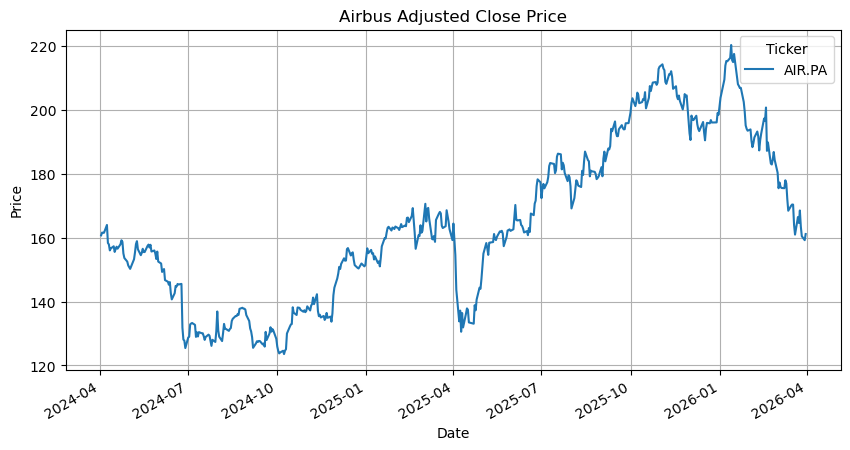

In [8]:
# Plot Airbus price
airbus["Adj Close"].plot(figsize=(10,5))
plt.title("Airbus Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [9]:
# Compute daily log returns
# Daily log returns are used because they are additive and commonly used in quantitative finance
airbus["log_return"] = np.log(airbus["Adj Close"] / airbus["Adj Close"].shift(1))
airbus = airbus.dropna()
airbus.head()

Price,Adj Close,log_return
Ticker,AIR.PA,
Date,,
2024-04-03,161.552200,0.005370
2024-04-04,161.456070,-0.000595
2024-04-05,161.513733,0.000357
2024-04-08,163.936157,0.014887
2024-04-09,158.303055,-0.034966


### Volatility estimation

The Black-Scholes model assumes constant volatility.

Since volatility varies over time, we estimate
current volatility using rolling windows
of 20 and 60 trading days.

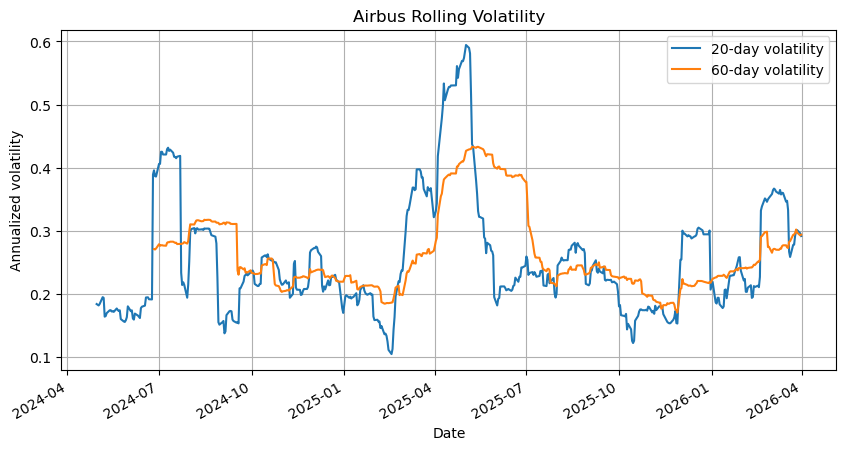

20-day volatility: 0.2918
60-day volatility: 0.2939


In [10]:
# Rolling historical volatility
airbus["vol_20d"] = airbus["log_return"].rolling(20).std() * np.sqrt(252)
airbus["vol_60d"] = airbus["log_return"].rolling(60).std() * np.sqrt(252)

# Volatility plot
plt.figure(figsize=(10,5))
airbus["vol_20d"].plot(label="20-day volatility")
airbus["vol_60d"].plot(label="60-day volatility")
plt.title("Airbus Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.legend()
plt.grid(True)
plt.show()


# Latest volatility estimates
sigma_20 = airbus["vol_20d"].dropna().iloc[-1]
sigma_60 = airbus["vol_60d"].dropna().iloc[-1]

print("20-day volatility:", round(sigma_20,4))
print("60-day volatility:", round(sigma_60,4))

In [11]:
# Black-Scholes parameters

# Get latest Airbus price to get S0
latest_airbus = yf.download("AIR.PA",period="5d",auto_adjust=False)
S0 = latest_airbus["Adj Close"].dropna().iloc[-1] 
print("Current Airbus price:", round(S0,4))
print()

r = 0.02
T_30 = 30 / 252
T_90 = 90 / 252


# Strike values around the spot price (from 90% to 110% of the current spot price)
strikes = [0.90 * S0,0.95 * S0,1.00 * S0,1.05 * S0,1.10 * S0]
strikes = [round(k,2) for k in strikes]
print(strikes)

[*********************100%***********************]  1 of 1 completed

Current Airbus price: Ticker
AIR.PA    161.1
Name: 2026-03-31 00:00:00, dtype: float64

[Ticker
AIR.PA    144.99
Name: 2026-03-31 00:00:00, dtype: float64, Ticker
AIR.PA    153.05
Name: 2026-03-31 00:00:00, dtype: float64, Ticker
AIR.PA    161.1
Name: 2026-03-31 00:00:00, dtype: float64, Ticker
AIR.PA    169.16
Name: 2026-03-31 00:00:00, dtype: float64, Ticker
AIR.PA    177.21
Name: 2026-03-31 00:00:00, dtype: float64]


In [12]:
# Black-Scholes pricing functions

def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price


def bs_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return put_price



def to_scalar(x):
    if isinstance(x, pd.Series):
        return float(x.iloc[0])
    return float(x)

# Compute Black-Scholes pricing table
results = []

for K in strikes:
    K_value = to_scalar(K)

    results.append({
        "Strike": K_value,

        "Call_30d_sigma20": to_scalar(bs_call(S0, K_value, T_30, r, sigma_20)),
        "Put_30d_sigma20": to_scalar(bs_put(S0, K_value, T_30, r, sigma_20)),

        "Call_30d_sigma60": to_scalar(bs_call(S0, K_value, T_30, r, sigma_60)),
        "Put_30d_sigma60": to_scalar(bs_put(S0, K_value, T_30, r, sigma_60)),

        "Call_90d_sigma20": to_scalar(bs_call(S0, K_value, T_90, r, sigma_20)),
        "Put_90d_sigma20": to_scalar(bs_put(S0, K_value, T_90, r, sigma_20)),

        "Call_90d_sigma60": to_scalar(bs_call(S0, K_value, T_90, r, sigma_60)),
        "Put_90d_sigma60": to_scalar(bs_put(S0, K_value, T_90, r, sigma_60))
    })

pricing_table = pd.DataFrame(results).round(4)
pricing_table

,Strike,Call_30d_sigma20,Put_30d_sigma20,Call_30d_sigma60,Put_30d_sigma60,Call_90d_sigma20,Put_90d_sigma20,Call_90d_sigma60,Put_90d_sigma60
0,144.99,17.5724,1.1176,17.5972,1.1424,21.2931,4.1511,21.3544,4.2125
1,153.05,11.3787,2.9648,11.4178,3.0038,16.0485,6.9092,16.1219,6.9825
2,161.10,6.6539,6.2708,6.7000,6.3169,11.7366,10.5900,11.8161,10.6695
3,169.16,3.4845,11.1422,3.5270,11.1847,8.3281,15.1841,8.4073,15.2633
4,177.21,1.6346,17.3231,1.6663,17.3548,5.7459,20.5946,5.8194,20.6681


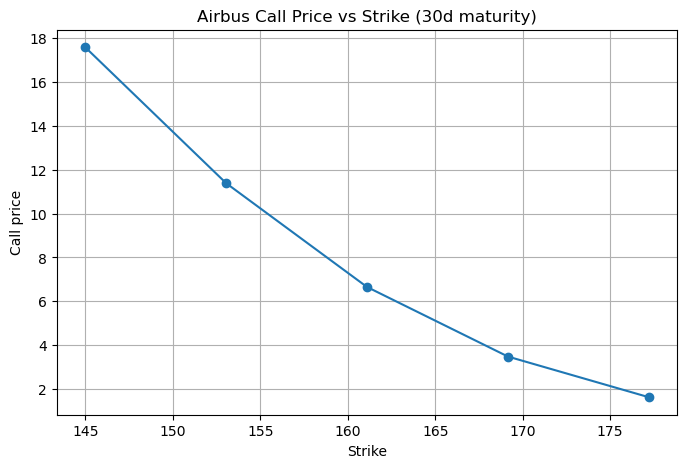

In [13]:
pricing_table = pricing_table.astype(float)
plt.figure(figsize=(8,5))
plt.plot(pricing_table["Strike"],pricing_table["Call_30d_sigma20"],marker="o")
plt.title("Airbus Call Price vs Strike (30d maturity)")
plt.xlabel("Strike")
plt.ylabel("Call price")
plt.grid(True)
plt.show()

The current price of Airbus is 161.10000610351562


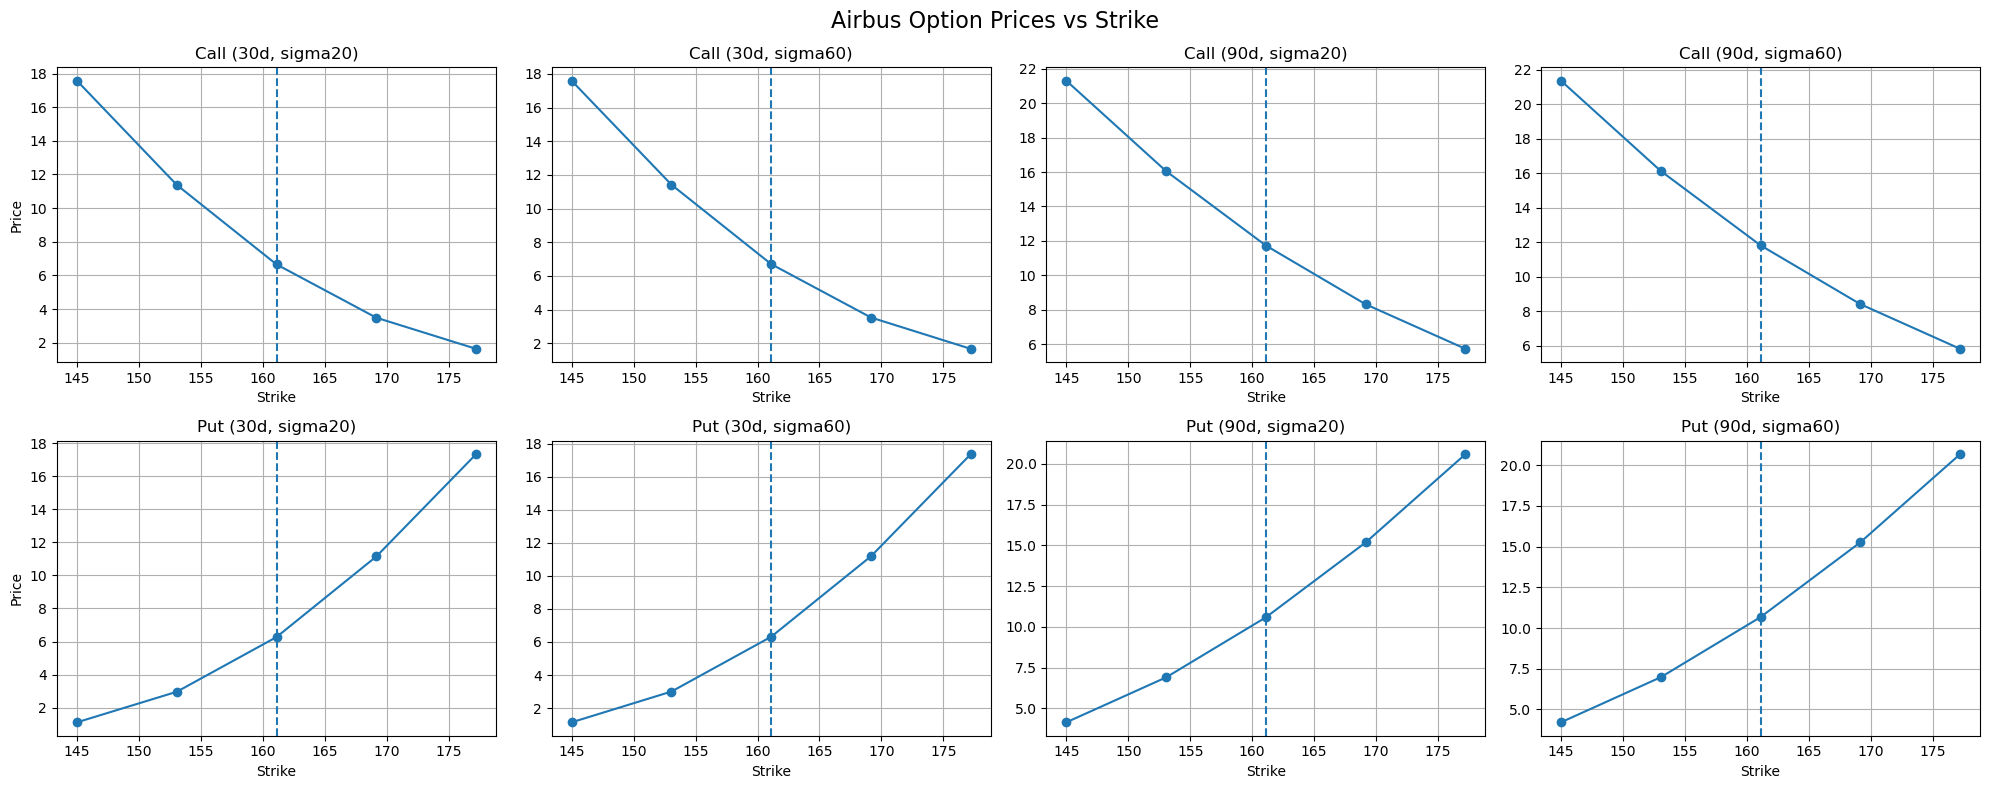

In [14]:
print(f"The current price of Airbus is {S0.iloc[-1]}")

fig, axes = plt.subplots(2, 4, figsize=(20,8))

fig.suptitle("Airbus Option Prices vs Strike", fontsize=16)

# --- CALL OPTIONS ---

axes[0,0].plot(pricing_table["Strike"], pricing_table["Call_30d_sigma20"], marker="o")
axes[0,0].axvline(x=S0.iloc[-1], linestyle="--")
axes[0,0].set_title("Call (30d, sigma20)")
axes[0,0].set_xlabel("Strike")
axes[0,0].set_ylabel("Price")
axes[0,0].grid(True)

axes[0,1].plot(pricing_table["Strike"], pricing_table["Call_30d_sigma60"], marker="o")
axes[0,1].axvline(x=S0.iloc[-1], linestyle="--")
axes[0,1].set_title("Call (30d, sigma60)")
axes[0,1].set_xlabel("Strike")
axes[0,1].grid(True)

axes[0,2].plot(pricing_table["Strike"], pricing_table["Call_90d_sigma20"], marker="o")
axes[0,2].axvline(x=S0.iloc[-1], linestyle="--")
axes[0,2].set_title("Call (90d, sigma20)")
axes[0,2].set_xlabel("Strike")
axes[0,2].grid(True)

axes[0,3].plot(pricing_table["Strike"], pricing_table["Call_90d_sigma60"], marker="o")
axes[0,3].axvline(x=S0.iloc[-1], linestyle="--")
axes[0,3].set_title("Call (90d, sigma60)")
axes[0,3].set_xlabel("Strike")
axes[0,3].grid(True)


# --- PUT OPTIONS ---

axes[1,0].plot(pricing_table["Strike"], pricing_table["Put_30d_sigma20"], marker="o")
axes[1,0].axvline(x=S0.iloc[-1], linestyle="--")
axes[1,0].set_title("Put (30d, sigma20)")
axes[1,0].set_xlabel("Strike")
axes[1,0].set_ylabel("Price")
axes[1,0].grid(True)

axes[1,1].plot(pricing_table["Strike"], pricing_table["Put_30d_sigma60"], marker="o")
axes[1,1].axvline(x=S0.iloc[-1], linestyle="--")
axes[1,1].set_title("Put (30d, sigma60)")
axes[1,1].set_xlabel("Strike")
axes[1,1].grid(True)

axes[1,2].plot(pricing_table["Strike"], pricing_table["Put_90d_sigma20"], marker="o")
axes[1,2].axvline(x=S0.iloc[-1], linestyle="--")
axes[1,2].set_title("Put (90d, sigma20)")
axes[1,2].set_xlabel("Strike")
axes[1,2].grid(True)

axes[1,3].plot(pricing_table["Strike"], pricing_table["Put_90d_sigma60"], marker="o")
axes[1,3].axvline(x=S0.iloc[-1], linestyle="--")
axes[1,3].set_title("Put (90d, sigma60)")
axes[1,3].set_xlabel("Strike")
axes[1,3].grid(True)

plt.tight_layout()
plt.show()

## Sensitivity analysis

In this section, we analyse how Black-Scholes prices react to changes in:

- the risk-free rate
- volatility
- time to maturity

This helps understand the economic behaviour of the model.

In [15]:
# Base case for sensitivity analysis

K_base = round(S0, 2)      # ATM strike
r_base = 0.02
sigma_base = sigma_20
T_base = 30 / 252

print("Base case")
print("S0      :", round(S0, 4))
print("K_base  :", K_base)
print("r_base  :", r_base)
print("sigma   :", round(sigma_base, 4))
print("T_base  :", round(T_base, 4))

Base case
S0      : Ticker
AIR.PA    161.1
Name: 2026-03-31 00:00:00, dtype: float64
K_base  : Ticker
AIR.PA    161.1
Name: 2026-03-31 00:00:00, dtype: float64
r_base  : 0.02
sigma   : 0.2918
T_base  : 0.119


### Sensitivity to the risk-free rate

We study how option prices react to different values of the risk-free rate:

- 0%
- 2%
- 4%

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/matplotlib/cbook.py:1355: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


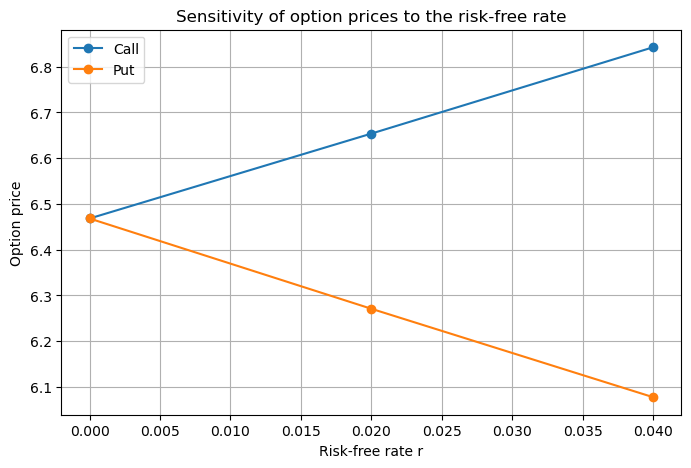

In [16]:
# Sensitivity to the risk-free rate
r_values = [0.00, 0.02, 0.04]
r_results = []

for r_test in r_values:
    call_price = bs_call(S0, K_base, T_base, r_test, sigma_base)
    put_price = bs_put(S0, K_base, T_base, r_test, sigma_base)
    r_results.append({
        "Risk-free rate": r_test,
        "Call price": call_price,
        "Put price": put_price})

r_table = pd.DataFrame(r_results).round(6)
r_table


plt.figure(figsize=(8,5))
plt.plot(r_table["Risk-free rate"], r_table["Call price"], marker="o", label="Call")
plt.plot(r_table["Risk-free rate"], r_table["Put price"], marker="o", label="Put")
plt.title("Sensitivity of option prices to the risk-free rate")
plt.xlabel("Risk-free rate r")
plt.ylabel("Option price")

plt.legend()
plt.grid(True)
plt.show()

### Interpretation

As the risk-free rate increases:

- call prices tend to increase
- put prices tend to decrease

This is consistent with the Black-Scholes formula, where the strike is discounted
at the risk-free rate.

### Sensitivity to volatility

We compare two historical volatility estimates:

- 20-day historical volatility
- 60-day historical volatility

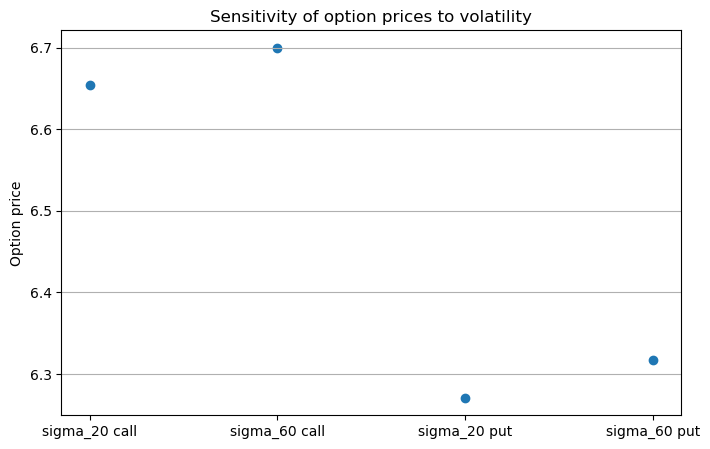

In [17]:
# Sensitivity to volatility
sigma_results = []

for sigma_test, label in [(sigma_20, "sigma_20"), (sigma_60, "sigma_60")]:
    call_price = bs_call(S0, K_base, T_base, r_base, sigma_test)
    put_price = bs_put(S0, K_base, T_base, r_base, sigma_test)
    sigma_results.append({
        "Volatility label": label,
        "Volatility value": sigma_test,
        "Call price": call_price,
        "Put price": put_price})

sigma_table = pd.DataFrame(sigma_results).round(6)
sigma_table### Sensitivity to volatility

plt.figure(figsize=(8,5))
plt.scatter(["sigma_20 call", "sigma_60 call", "sigma_20 put", "sigma_60 put"],
    [sigma_table.loc[0, "Call price"].item(),
    sigma_table.loc[1, "Call price"].item(),
    sigma_table.loc[0, "Put price"].item(),
    sigma_table.loc[1, "Put price"].item()])
plt.title("Sensitivity of option prices to volatility")
plt.ylabel("Option price")
plt.grid(True, axis="y")
plt.show()

### Interpretation

A higher volatility increases the uncertainty of the terminal stock price (20-day volatility lower than 60-day volatility in this case).
As a result, both call and put prices generally increase when volatility increases. 

### Sensitivity to time to maturity

We compare two maturities:

- 30 trading days
- 90 trading days

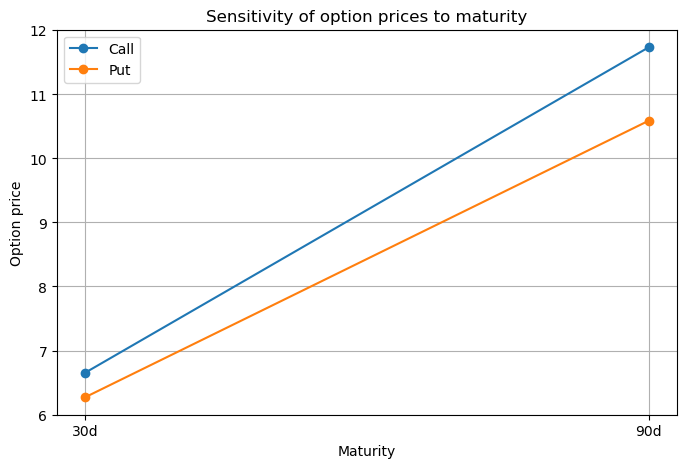

In [18]:
# Sensitivity to maturity
T_values = [(30 / 252, "30d"), (90 / 252, "90d")]
T_results = []

for T_test, label in T_values:
    call_price = bs_call(S0, K_base, T_test, r_base, sigma_base)
    put_price = bs_put(S0, K_base, T_test, r_base, sigma_base)
    T_results.append({
        "Maturity label": label,
        "Maturity value": T_test,
        "Call price": call_price,
        "Put price": put_price})

T_table = pd.DataFrame(T_results).round(6)
T_table

plt.figure(figsize=(8,5))
plt.plot(T_table["Maturity label"], T_table["Call price"], marker="o", label="Call")
plt.plot(T_table["Maturity label"], T_table["Put price"], marker="o", label="Put")
plt.title("Sensitivity of option prices to maturity")
plt.xlabel("Maturity")
plt.ylabel("Option price")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

A longer maturity gives the option more time to end up in-the-money.

This generally increases the value of both call and put options.

In [19]:
summary_sensitivity = pd.DataFrame({
    "Parameter": [
        "r = 0%",
        "r = 2%",
        "r = 4%",
        "sigma_20",
        "sigma_60",
        "T = 30d",
        "T = 90d"
    ],
    "Call price": [
        r_table["Call price"].iloc[0].item(),
        r_table["Call price"].iloc[1].item(),
        r_table["Call price"].iloc[2].item(),
        sigma_table["Call price"].iloc[0].item(),
        sigma_table["Call price"].iloc[1].item(),
        T_table["Call price"].iloc[0].item(),
        T_table["Call price"].iloc[1].item(),
    ],
    "Put price": [
        r_table["Put price"].iloc[0].item(),
        r_table["Put price"].iloc[1].item(),
        r_table["Put price"].iloc[2].item(),
        sigma_table["Put price"].iloc[0].item(),
        sigma_table["Put price"].iloc[1].item(),
        T_table["Put price"].iloc[0].item(),
        T_table["Put price"].iloc[1].item(),
    ]
}).round(6)

summary_sensitivity

,Parameter,Call price,Put price
0,r = 0%,6.468223,6.468216
1,r = 2%,6.653894,6.270773
2,r = 4%,6.842728,6.077403
3,sigma_20,6.653894,6.270773
4,sigma_60,6.700027,6.316906
5,T = 30d,6.653894,6.270773
6,T = 90d,11.736637,10.590016


## Model limitations

The Black-Scholes model is useful and elegant, but it relies on strong assumptions.

It is therefore important to understand its limitations before using it
as a market pricing tool.

### Main limitations of the Black-Scholes model

1. **Constant volatility**
   The model assumes that volatility is constant through time, whereas
   market volatility is stochastic and varies significantly.

2. **Lognormal dynamics**
   The stock price is assumed to follow a geometric Brownian motion,
   which excludes jumps and more complex market behaviour.

3. **Constant interest rate**
   The risk-free rate is assumed to be constant.

4. **No dividends / simplified market environment**
   The model is usually presented in a simplified framework without
   transaction costs, taxes or liquidity effects.

5. **European exercise only**
   The Black-Scholes analytical formula applies to European options only,
   not to American options which can be exercised before maturity.

### Practical interpretation

Despite its limitations, the Black-Scholes model remains a fundamental
benchmark in quantitative finance.

It is useful for:
- understanding option pricing mechanisms
- analysing sensitivities
- benchmarking numerical methods such as Monte Carlo